<center>

# [Компьютерное зрение](http://rairi.ru/wiki/index.php/%D0%9A%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5)

## <center> Семинар 11 - Трекинг

<a target="_blank" href="https://colab.research.google.com/github/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_11/Seminar_11.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

---


In [1]:
# !pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116
# !pip install ultralytics filterpy lap
# !pip uninstall -y numpy protobuf
# !pip install -U numpy==1.23.5 protobuf==3.20.3

In [2]:
from typing import Tuple
from time import time
import types
from pathlib import Path

from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Вспомогательные функции


In [3]:
def show_image(img: np.ndarray) -> None:
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.show()


def detection_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
    return img


def tracking_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0]), int(preds[i][1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=2,
            color=(0, 255, 0),
            thickness=3
        )
    return img


# Датасет

В рамках данного семинара мы будем использовать трек `MOT17-09` из датасета MOT Challenge https://motchallenge.net/

Ссылка на скачивание датасета https://motchallenge.net/data/MOT17Det/


In [4]:
dataset_dir = Path("data/MOT17_09_imgs")  # путь к директории с изображениями трека MOT17-09
frames_list = sorted([f for f in dataset_dir.iterdir()])

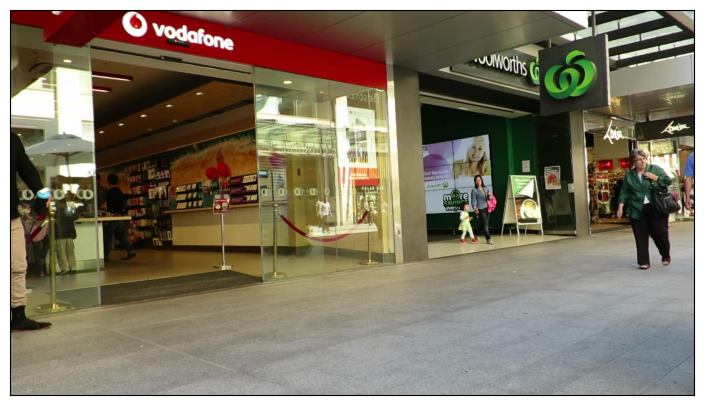

In [5]:
img = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
show_image(img)

# Детекция с помощью YOLOv8

В качестве бэкбона детекции мы будем использовать YOLOv8s из библиотеки ultralytics: https://github.com/ultralytics/ultralytics


In [6]:
class YoloDetector:
    def __init__(self, conf_threshold: float = 0.5) -> None:
        self.backbone = YOLO("yolov8s.pt")
        self.conf_threshold = conf_threshold

    def __call__(self, img_path: Path) -> np.ndarray:
        preds = self.backbone.predict(source=img_path, conf=self.conf_threshold, show=False, classes=0)
        preds = preds[0].boxes.data.cpu().numpy()[:, :5]
        return preds


image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000001.jpg: 384x640 7 persons, 55.5ms
Speed: 1.5ms preprocess, 55.5ms inference, 26.5ms postprocess per image at shape (1, 3, 384, 640)


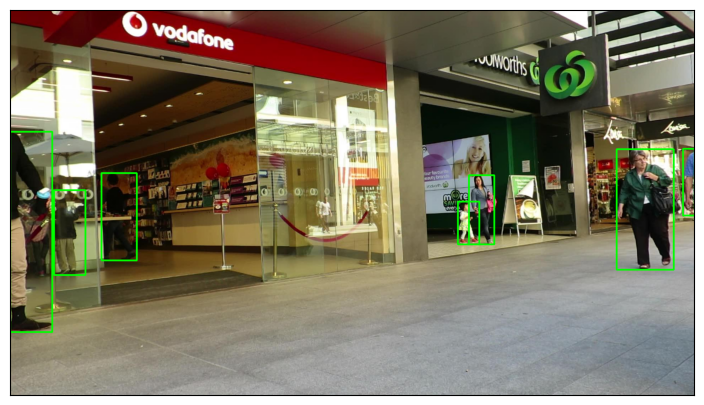

In [7]:
detector = YoloDetector()
preds = detector(frames_list[0])

out_frame = detection_visualization(frames_list[0], preds)
show_image(out_frame)

# Алгоритм трекинга SORT

SORT: https://arxiv.org/abs/1602.00763

Разделы "3.3. Data Association" и "3.4. Creation and Deletion of Track Identities" описывают алгоритм соотнесения результатов детекции последовательных кадров:

> **3.3. Data Association**
>
> In assigning detections to existing targets, each target’s
> bounding box geometry is estimated by predicting its new
> location in the current frame. The assignment cost matrix is
> then computed as the intersection-over-union (IOU) distance
> between each detection and all predicted bounding boxes
> from the existing targets. The assignment is solved optimally
> using the Hungarian algorithm. Additionally, a minimum
> IOU is imposed to reject assignments where the detection to
> target overlap is less than $IOU_{min}$.
>
> We found that the IOU distance of the bounding boxes
> implicitly handles short term occlusion caused by passing targets.
> Specifically, when a target is covered by an occluding
> object, only the occluder is detected, since the IOU distance
> appropriately favours detections with similar scale. This allows
> both the occluder target to be corrected with the detection while
> the covered target is unaffected as no assignment is made.

> **3.4. Creation and Deletion of Track Identities**
>
> When objects enter and leave the image, unique identities
> need to be created or destroyed accordingly. For creating
> trackers, we consider any detection with an overlap less than
> $IOU_{min}$ to signify the existence of an untracked object. The
> tracker is initialised using the geometry of the bounding box
> with the velocity set to zero. Since the velocity is unobserved
> at this point the covariance of the velocity component is initialised
> with large values, reflecting this uncertainty. Additionally, the new
> tracker then undergoes a probationary period where the target needs
> to be associated with detections to accumulate enough evidence in order
> to prevent tracking of false positives.
>
> Tracks are terminated if they are not detected for $T_{Lost}$
> frames. This prevents an unbounded growth in the number
> of trackers and localisation errors caused by predictions over
> long durations without corrections from the detector. In all
> experiments $T_{Lost}$ is set to 1 for two reasons. Firstly, the constant
> velocity model is a poor predictor of the true dynamics
> and secondly we are primarily concerned with frame-to-frame
> tracking where object re-identification is beyond the scope of
> this work. Additionally, early deletion of lost targets aids efficiency.
> Should an object reappear, tracking will implicitly resume under a new identity.


# Венгерский алгоритм (Hungarian algorithm)

- [Wikipedia](https://en.wikipedia.org/wiki/Hungarian_algorithm)
- Реализация в библиотеке scipy: [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- Реализация в библиотеке [lap](https://github.com/gatagat/lap): `lap.lapjv`

## Задание 1:

Реализуйте Венгерский алгоритм. Сравните возвращаемые значения с библиотечной функцией [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).


In [8]:
def hungarian_algorithm(cost_matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solves the assignment problem using the Hungarian algorithm.

    Args:
        cost_matrix (np.ndarray): Numpy array of shape (n, m) representing the cost matrix.

    Returns:
        A tuple of two numpy arrays (row_ind, col_ind) representing the row and column indices
        of the assigned cells in the cost matrix.
    """

    # Венгерский алгоритм решает задачу о назначениях:
    # нужно сопоставить объекты так, чтобы каждый был выбран только один раз,
    # а суммарная стоимость соответствий была минимальной.
    #
    # На практике часто используется в трекинге объектов,
    # когда нужно сопоставить детекции на текущем кадре с прошлыми треками.
    #
    # Идея алгоритма такая:
    # мы хотим назначить каждой строке один столбец с минимальной общей стоимостью.
    #
    # Алгоритм не перебирает все варианты, а использует потенциалы
    # строк и столбцов, чтобы удобно искать улучшение текущего назначения.
    #
    # На каждом шаге мы добавляем новую строку:
    # ищем для нее столбец, а если он уже занят,
    # перестраиваем текущие назначения по цепочке.
    #
    # В итоге алгоритм постепенно улучшает matching
    # и находит оптимальное решение.


    # Приводим матрицу к float, чтобы удобно работать с разностями
    cost_matrix = np.array(cost_matrix, dtype=float)

    if cost_matrix.ndim != 2:
        raise ValueError("cost_matrix must be 2-dimensional")

    n, m = cost_matrix.shape

    # Если матрица пустая, назначений нет
    if n == 0 or m == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    # Если строк больше, чем столбцов, решаем задачу для транспонированной матрицы
    transposed = False
    if n > m:
        cost_matrix = cost_matrix.T
        n, m = cost_matrix.shape
        transposed = True

    # u и v — потенциалы строк и столбцов
    u = np.zeros(n + 1)
    v = np.zeros(m + 1)

    # p[j] = номер строки, которая сейчас назначена на столбец j
    p = np.zeros(m + 1, dtype=int)

    # way[j] нужен для восстановления пути
    way = np.zeros(m + 1, dtype=int)

    # Постепенно добавляем строки в текущее решение
    for i in range(1, n + 1):
        p[0] = i
        minv = np.full(m + 1, np.inf)
        used = np.zeros(m + 1, dtype=bool)
        j0 = 0

        while True:
            used[j0] = True
            i0 = p[j0]
            delta = np.inf
            j1 = 0

            # Ищем лучший столбец для текущего шага
            for j in range(1, m + 1):
                if not used[j]:
                    cur = cost_matrix[i0 - 1, j - 1] - u[i0] - v[j]

                    if cur < minv[j]:
                        minv[j] = cur
                        way[j] = j0

                    if minv[j] < delta:
                        delta = minv[j]
                        j1 = j

            # Обновляем потенциалы
            for j in range(m + 1):
                if used[j]:
                    u[p[j]] += delta
                    v[j] -= delta
                else:
                    minv[j] -= delta

            j0 = j1

            # Если нашли свободный столбец, можно восстанавливать путь
            if p[j0] == 0:
                break

        # Перестраиваем matching
        while True:
            j1 = way[j0]
            p[j0] = p[j1]
            j0 = j1
            if j0 == 0:
                break

    # Восстанавливаем ответ
    row_to_col = np.full(n, -1, dtype=int)
    for j in range(1, m + 1):
        if p[j] != 0:
            row_to_col[p[j] - 1] = j - 1

    if not transposed:
        row_ind = np.arange(n, dtype=int)
        col_ind = row_to_col
    else:
        row_ind = row_to_col
        col_ind = np.arange(n, dtype=int)
        order = np.argsort(row_ind)
        row_ind = row_ind[order]
        col_ind = col_ind[order]

    return row_ind, col_ind

In [9]:
cost_matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
my_row_ind, my_col_ind = hungarian_algorithm(cost_matrix)
my_cost = cost_matrix[my_row_ind, my_col_ind].sum()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost = cost_matrix[row_ind, col_ind].sum()

assert my_cost == cost

# Алгоритм трекинга ByteTrack

- Статья https://arxiv.org/abs/2110.06864
- Код https://github.com/ifzhang/ByteTrack


## Вопрос 1:

В чем заключается ключевая особенность метода BYTE?

**Ответ:**
Ключевая особенность BYTE в том, что он использует не только детекции с высоким скором, но и детекции с низким скором. В обычных методах такие боксы часто сразу отбрасываются, из-за чего трек может потеряться, например при перекрытии объекта или неуверенной детекции.

В BYTE сначала сопоставляются надежные детекции, а потом дополнительно рассматриваются детекции с низким score для оставшихся треков. За счет этого метод лучше восстанавливает объекты, уменьшает число пропусков и делает траектории более стабильными.


In [10]:
# !git clone https://github.com/ifzhang/ByteTrack.git
# %cd ByteTrack
# !pip install -r requirements.txt
# !python setup.py develop
# %cd ..
# !pip install cython
# !pip install 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
# !pip install cython_bbox

In [11]:
import sys
sys.path.append("/home/work/WORK/MIPT/study/repos/ByteTrack")

import numpy as np

# Небольшой workaround для старого ByteTrack и нового numpy
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "bool"):
    np.bool = bool

from yolox.tracker.byte_tracker import BYTETracker

fps = 30
frame_size = (1080, 1920)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_file = 'output.mp4'
video_writer = cv2.VideoWriter(output_file, fourcc, fps, frame_size[::-1])

args = types.SimpleNamespace(**{
    "track_thresh": 0.5,
    "track_buffer": 30,
    "match_thresh": 0.8,
    "mot20": False,

})
tracker = BYTETracker(args, frame_rate=fps)

det_times = []
track_times = []

for frame_path in frames_list:
    s_time = time()
    detections = detector(frame_path)
    det_times.append((time() - s_time) * 1000)  # in ms
    s_time = time()
    tracks = tracker.update(detections, frame_size, frame_size)
    track_times.append((time() - s_time) * 1000)  # in ms
    tracks = [t.tlbr.tolist() + [t.track_id] for t in tracks]
    out_frame = tracking_visualization(frame_path, tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
    # cv2.imwrite(f"./output/{str(frame_path.name)}", cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
video_writer.release()

print(f"mean detection time: {np.mean(det_times)}, mean track time: {np.mean(track_times)}")

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000001.jpg: 384x640 7 persons, 9.7ms
Speed: 2.8ms preprocess, 9.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000002.jpg: 384x640 7 persons, 6.4ms
Speed: 2.2ms preprocess, 6.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000003.jpg: 384x640 7 persons, 5.0ms
Speed: 1.4ms preprocess, 5.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000004.jpg: 384x640 7 persons, 4.9ms
Speed: 1.4ms preprocess, 4.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_1

## Задание 2

Объедините BYTE и любой трекер с Re-ID признаками (например, FairMOT). Можно воспользоваться инструкциями из репозитория: https://github.com/ifzhang/ByteTrack/tree/main/tutorials

Ответом на это задание должен быть код, записывающий видео работы метода для трека MOT17-09 в файл `reid_out.mp4`. Убедитесь, что код работает "end-to-end".


**Решение**

В этом решении в качестве трекера с Re-ID признаками используется DeepSORT из репозитория ByteTrack:
https://github.com/ifzhang/ByteTrack

DeepSORT отличается от обычного SORT тем, что использует не только информацию о движении объекта, но и признаки его внешнего вида, поэтому лучше сохраняет `id` при перекрытиях, похожих траекториях и кратковременных пропаданиях объекта.

Дальше эта идея объединяется с BYTE.  
В этом решении используется логика BYTE для двухэтапного сопоставления детекций, но дополнительно добавлены еще Re-ID признаки.  
Сначала треки сопоставляются с надежными детекциями по appearance + motion, потом оставшиеся треки добираются по IoU, и отдельно используются low-score детекции, как в BYTE.


In [15]:
# сначала скачаем веса:
!mkdir -p /home/work/WORK/MIPT/study/repos/ByteTrack/pretrained
!pip install -q gdown
!gdown --folder "https://drive.google.com/drive/folders/1xhG0kRH1EX5B9_Iz8gQJb7UNnn_riXi6" -O /home/work/WORK/MIPT/study/repos/ByteTrack/pretrained

/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home

In [16]:
!ls -lh /home/work/WORK/MIPT/study/repos/ByteTrack/pretrained/ckpt.t7

/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
/bin/bash: /home/work/miniconda3/envs/mlops/lib/libreadline.so.8: no version information available (required by /bin/bash)
-rw------- 1 work work 44M сен 26  2018 /home/work/WORK/MIPT/study/repos/ByteTrack/pretrained/ckpt.t7


In [19]:
import sys
from pathlib import Path
from collections import deque
import types

import cv2
import numpy as np

# Небольшой workaround для старого ByteTrack и нового numpy
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "bool"):
    np.bool = bool

# Путь к репозиторию ByteTrack
BYTE_TRACK_HOME = Path("/home/work/WORK/MIPT/study/repos/ByteTrack")
if str(BYTE_TRACK_HOME) not in sys.path:
    sys.path.append(str(BYTE_TRACK_HOME))

from yolox.tracker import matching
from yolox.tracker.kalman_filter import KalmanFilter
from yolox.tracker.basetrack import BaseTrack, TrackState
from yolox.deepsort_tracker.reid_model import Extractor


class ReIDSTrack(BaseTrack):
    shared_kalman = KalmanFilter()

    def __init__(self, tlwh, score, feat, buffer_size=30):
        # bbox в формате (x, y, w, h)
        self._tlwh = np.asarray(tlwh, dtype=float)

        self.kalman_filter = None
        self.mean, self.covariance = None, None
        self.is_activated = False

        self.score = float(score)
        self.tracklet_len = 0

        # Для Re-ID будем хранить текущий и сглаженный признак
        self.alpha = 0.9
        self.features = deque([], maxlen=buffer_size)
        self.smooth_feat = None
        self.curr_feat = None
        self.update_features(feat)

    def update_features(self, feat):
        feat = np.asarray(feat, dtype=np.float32)
        feat /= (np.linalg.norm(feat) + 1e-12)

        self.curr_feat = feat
        if self.smooth_feat is None:
            self.smooth_feat = feat
        else:
            self.smooth_feat = self.alpha * self.smooth_feat + (1 - self.alpha) * feat
            self.smooth_feat /= (np.linalg.norm(self.smooth_feat) + 1e-12)

        self.features.append(feat)

    def predict(self):
        mean_state = self.mean.copy()
        if self.state != TrackState.Tracked:
            mean_state[7] = 0
        self.mean, self.covariance = self.kalman_filter.predict(mean_state, self.covariance)

    @staticmethod
    def multi_predict(stracks):
        if len(stracks) == 0:
            return

        multi_mean = np.asarray([st.mean.copy() for st in stracks])
        multi_covariance = np.asarray([st.covariance for st in stracks])

        for i, st in enumerate(stracks):
            if st.state != TrackState.Tracked:
                multi_mean[i][7] = 0

        multi_mean, multi_covariance = ReIDSTrack.shared_kalman.multi_predict(
            multi_mean, multi_covariance
        )

        for i, (mean, cov) in enumerate(zip(multi_mean, multi_covariance)):
            stracks[i].mean = mean
            stracks[i].covariance = cov

    def activate(self, kalman_filter, frame_id):
        self.kalman_filter = kalman_filter
        self.track_id = self.next_id()
        self.mean, self.covariance = self.kalman_filter.initiate(
            self.tlwh_to_xyah(self._tlwh)
        )

        self.tracklet_len = 0
        self.state = TrackState.Tracked
        self.is_activated = frame_id == 1
        self.frame_id = frame_id
        self.start_frame = frame_id

    def re_activate(self, new_track, frame_id, new_id=False):
        self.mean, self.covariance = self.kalman_filter.update(
            self.mean, self.covariance, self.tlwh_to_xyah(new_track.tlwh)
        )
        self.update_features(new_track.curr_feat)

        self.tracklet_len = 0
        self.state = TrackState.Tracked
        self.is_activated = True
        self.frame_id = frame_id

        if new_id:
            self.track_id = self.next_id()

        self.score = new_track.score

    def update(self, new_track, frame_id):
        self.frame_id = frame_id
        self.tracklet_len += 1

        self.mean, self.covariance = self.kalman_filter.update(
            self.mean, self.covariance, self.tlwh_to_xyah(new_track.tlwh)
        )
        self.state = TrackState.Tracked
        self.is_activated = True
        self.score = new_track.score
        self.update_features(new_track.curr_feat)

    @property
    def tlwh(self):
        if self.mean is None:
            return self._tlwh.copy()

        ret = self.mean[:4].copy()
        ret[2] *= ret[3]
        ret[:2] -= ret[2:] / 2
        return ret

    @property
    def tlbr(self):
        ret = self.tlwh.copy()
        ret[2:] += ret[:2]
        return ret

    @staticmethod
    def tlwh_to_xyah(tlwh):
        ret = np.asarray(tlwh).copy()
        ret[:2] += ret[2:] / 2
        ret[2] /= ret[3]
        return ret
    
    def to_xyah(self):
        return self.tlwh_to_xyah(self.tlwh)

    @staticmethod
    def tlbr_to_tlwh(tlbr):
        ret = np.asarray(tlbr).copy()
        ret[2:] -= ret[:2]
        return ret


def joint_stracks(tlista, tlistb):
    exists = {}
    res = []

    for t in tlista:
        exists[t.track_id] = 1
        res.append(t)

    for t in tlistb:
        if not exists.get(t.track_id, 0):
            exists[t.track_id] = 1
            res.append(t)

    return res


def sub_stracks(tlista, tlistb):
    stracks = {t.track_id: t for t in tlista}
    for t in tlistb:
        if t.track_id in stracks:
            del stracks[t.track_id]
    return list(stracks.values())


def remove_duplicate_stracks(stracksa, stracksb):
    pdist = matching.iou_distance(stracksa, stracksb)
    pairs = np.where(pdist < 0.15)

    dupa, dupb = [], []
    for p, q in zip(*pairs):
        timep = stracksa[p].frame_id - stracksa[p].start_frame
        timeq = stracksb[q].frame_id - stracksb[q].start_frame
        if timep > timeq:
            dupb.append(q)
        else:
            dupa.append(p)

    resa = [t for i, t in enumerate(stracksa) if i not in dupa]
    resb = [t for i, t in enumerate(stracksb) if i not in dupb]
    return resa, resb


class ByteReIDTracker:
    def __init__(
        self,
        reid_model_path: Path,
        track_thresh: float = 0.5,
        track_buffer: int = 30,
        match_thresh: float = 0.8,
        frame_rate: int = 30,
        use_cuda: bool = True,
    ):
        self.track_thresh = track_thresh
        self.det_thresh = track_thresh + 0.1
        self.match_thresh = match_thresh
        self.max_time_lost = int(frame_rate / 30.0 * track_buffer)

        self.extractor = Extractor(str(reid_model_path), use_cuda=use_cuda)
        self.kalman_filter = KalmanFilter()

        self.tracked_stracks = []
        self.lost_stracks = []
        self.removed_stracks = []
        self.frame_id = 0

    def _build_stracks_from_dets(self, img_rgb: np.ndarray, dets: np.ndarray):
        if len(dets) == 0:
            return []

        h, w = img_rgb.shape[:2]
        valid_boxes = []
        crops = []

        for det in dets:
            x1, y1, x2, y2, score = det.astype(float)

            x1 = max(0, min(int(x1), w - 1))
            y1 = max(0, min(int(y1), h - 1))
            x2 = max(0, min(int(x2), w - 1))
            y2 = max(0, min(int(y2), h - 1))

            if x2 <= x1 or y2 <= y1:
                continue

            crop = img_rgb[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            valid_boxes.append((np.array([x1, y1, x2, y2], dtype=float), float(score)))
            crops.append(crop)

        if len(crops) == 0:
            return []

        feats = self.extractor(crops)
        detections = [
            ReIDSTrack(ReIDSTrack.tlbr_to_tlwh(box), score, feat, buffer_size=30)
            for (box, score), feat in zip(valid_boxes, feats)
        ]
        return detections

    def update(self, img_rgb: np.ndarray, detections_xyxy_score: np.ndarray):
        self.frame_id += 1

        activated_starcks = []
        refind_stracks = []
        lost_stracks = []
        removed_stracks = []

        if detections_xyxy_score is None or len(detections_xyxy_score) == 0:
            detections_xyxy_score = np.empty((0, 5), dtype=float)

        scores = detections_xyxy_score[:, 4] if len(detections_xyxy_score) > 0 else np.array([])
        bboxes = detections_xyxy_score[:, :4] if len(detections_xyxy_score) > 0 else np.empty((0, 4))

        remain_inds = scores > self.track_thresh
        inds_low = scores > 0.1
        inds_high = scores < self.track_thresh
        inds_second = np.logical_and(inds_low, inds_high)

        dets_high = detections_xyxy_score[remain_inds]
        dets_low = detections_xyxy_score[inds_second]

        detections = self._build_stracks_from_dets(img_rgb, dets_high)
        detections_second = self._build_stracks_from_dets(img_rgb, dets_low)

        unconfirmed = []
        tracked_stracks = []
        for track in self.tracked_stracks:
            if not track.is_activated:
                unconfirmed.append(track)
            else:
                tracked_stracks.append(track)

        # Шаг 1. BYTE + Re-ID: сначала матчим по appearance + motion
        strack_pool = joint_stracks(tracked_stracks, self.lost_stracks)
        ReIDSTrack.multi_predict(strack_pool)

        dists = matching.embedding_distance(strack_pool, detections)
        dists = matching.fuse_motion(self.kalman_filter, dists, strack_pool, detections)
        matches, u_track, u_detection = matching.linear_assignment(dists, thresh=self.match_thresh)

        for itracked, idet in matches:
            track = strack_pool[itracked]
            det = detections[idet]

            if track.state == TrackState.Tracked:
                track.update(det, self.frame_id)
                activated_starcks.append(track)
            else:
                track.re_activate(det, self.frame_id, new_id=False)
                refind_stracks.append(track)

        # Шаг 2. Оставшиеся high-score детекции матчим по IoU
        detections_remain = [detections[i] for i in u_detection]
        r_tracked_stracks = [
            strack_pool[i] for i in u_track if strack_pool[i].state == TrackState.Tracked
        ]

        dists = matching.iou_distance(r_tracked_stracks, detections_remain)
        matches, u_track, u_detection = matching.linear_assignment(dists, thresh=0.5)

        for itracked, idet in matches:
            track = r_tracked_stracks[itracked]
            det = detections_remain[idet]

            if track.state == TrackState.Tracked:
                track.update(det, self.frame_id)
                activated_starcks.append(track)
            else:
                track.re_activate(det, self.frame_id, new_id=False)
                refind_stracks.append(track)

        # Шаг 3. BYTE-идея: добираем оставшиеся треки low-score детекциями
        second_tracked_stracks = [
            r_tracked_stracks[i] for i in u_track if r_tracked_stracks[i].state == TrackState.Tracked
        ]

        dists = matching.iou_distance(second_tracked_stracks, detections_second)
        matches, u_track, u_detection_second = matching.linear_assignment(dists, thresh=0.4)

        for itracked, idet in matches:
            track = second_tracked_stracks[itracked]
            det = detections_second[idet]

            if track.state == TrackState.Tracked:
                track.update(det, self.frame_id)
                activated_starcks.append(track)
            else:
                track.re_activate(det, self.frame_id, new_id=False)
                refind_stracks.append(track)

        for it in u_track:
            track = second_tracked_stracks[it]
            if track.state != TrackState.Lost:
                track.mark_lost()
                lost_stracks.append(track)

        # Шаг 4. Работа с неподтвержденными треками
        detections_remain = [detections_remain[i] for i in u_detection]
        dists = matching.iou_distance(unconfirmed, detections_remain)
        matches, u_unconfirmed, u_detection = matching.linear_assignment(dists, thresh=0.7)

        for itracked, idet in matches:
            unconfirmed[itracked].update(detections_remain[idet], self.frame_id)
            activated_starcks.append(unconfirmed[itracked])

        for it in u_unconfirmed:
            track = unconfirmed[it]
            track.mark_removed()
            removed_stracks.append(track)

        # Шаг 5. Инициализация новых треков
        for inew in u_detection:
            track = detections_remain[inew]
            if track.score < self.det_thresh:
                continue
            track.activate(self.kalman_filter, self.frame_id)
            activated_starcks.append(track)

        # Шаг 6. Чистим слишком старые lost-треки
        for track in self.lost_stracks:
            if self.frame_id - track.end_frame > self.max_time_lost:
                track.mark_removed()
                removed_stracks.append(track)

        self.tracked_stracks = [t for t in self.tracked_stracks if t.state == TrackState.Tracked]
        self.tracked_stracks = joint_stracks(self.tracked_stracks, activated_starcks)
        self.tracked_stracks = joint_stracks(self.tracked_stracks, refind_stracks)

        self.lost_stracks = sub_stracks(self.lost_stracks, self.tracked_stracks)
        self.lost_stracks.extend(lost_stracks)
        self.lost_stracks = sub_stracks(self.lost_stracks, self.removed_stracks)

        self.removed_stracks.extend(removed_stracks)

        self.tracked_stracks, self.lost_stracks = remove_duplicate_stracks(
            self.tracked_stracks, self.lost_stracks
        )

        output_stracks = [track for track in self.tracked_stracks if track.is_activated]
        return output_stracks

In [20]:
# ---- запуск end-to-end ----

reid_model_path = BYTE_TRACK_HOME / "pretrained" / "ckpt.t7"
if not reid_model_path.exists():
    raise FileNotFoundError(
        f"Не найден файл весов Re-ID: {reid_model_path}\n"
        "Положите веса DeepSORT в ByteTrack/pretrained/ckpt.t7"
    )

first_frame = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
frame_h, frame_w = first_frame.shape[:2]

fps = 30
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter("reid_out.mp4", fourcc, fps, (frame_w, frame_h))

tracker = ByteReIDTracker(
    reid_model_path=reid_model_path,
    track_thresh=0.5,
    track_buffer=30,
    match_thresh=0.8,
    frame_rate=fps,
    use_cuda=True,
)

det_times = []
track_times = []

for frame_path in frames_list:
    img_bgr = cv2.imread(str(frame_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    s_time = time()
    detections = detector(frame_path)  # ожидаем формат [x1, y1, x2, y2, score]
    det_times.append((time() - s_time) * 1000)

    s_time = time()
    tracks = tracker.update(img_rgb, detections)
    track_times.append((time() - s_time) * 1000)

    # Оставим только адекватные боксы
    vis_tracks = []
    for t in tracks:
        tlwh = t.tlwh
        area = tlwh[2] * tlwh[3]
        vertical = tlwh[2] / max(tlwh[3], 1e-6) > 1.6

        if area > 100 and not vertical:
            vis_tracks.append(t.tlbr.tolist() + [t.track_id])

    out_frame = tracking_visualization(frame_path, vis_tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))

video_writer.release()

print(f"saved to: reid_out.mp4")
print(f"mean detection time: {np.mean(det_times):.3f} ms")
print(f"mean track time: {np.mean(track_times):.3f} ms")



image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000001.jpg: 384x640 7 persons, 5.5ms
Speed: 1.5ms preprocess, 5.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000002.jpg: 384x640 7 persons, 5.0ms
Speed: 1.4ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000003.jpg: 384x640 7 persons, 5.0ms
Speed: 1.4ms preprocess, 5.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_11/data/MOT17_09_imgs/000004.jpg: 384x640 7 persons, 5.0ms
Speed: 1.4ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/work/WORK/MIPT/study/repos/cv_course_2026/seminars/seminar_